# Running the Deutsch–Jozsa Algorithm on Real Quantum Hardware

In this notebook we execute the Deutsch–Jozsa algorithm on a real quantum computer provided by IBM Quantum.

The goal is to compare the results obtained from a simulator with those obtained from real hardware, where noise and decoherence may affect the measurement outcomes.

In [23]:
import sys
sys.path.append("../src")
import json
from qiskit import transpile
from qiskit.visualization import plot_histogram
from quantum import build_deutsch_jozsa

In [14]:
"""
Set up the connection to IBM Quantum Service.
This allows the execution of the Deutsch-Jozsa circuit 
on real quantum backends or cloud-based simulators.
"""

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-03-17 02:49:22,822: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: quantum-lab. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [ ]:
# List all available quantum backends and simulators
service.backends()

qiskit_runtime_service.backends:WARNING:2026-03-17 02:27:11,969: Loading instance: quantum-lab, plan: open


[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_kingston')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_torino')>]

In [6]:
# Choosing a quantum computer
backend = service.least_busy(
    operational=True,
    simulator=False
)

backend

qiskit_runtime_service.backends:WARNING:2026-03-17 02:34:03,487: Loading instance: quantum-lab, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-17 02:34:06,198: Using instance: quantum-lab, plan: open


<IBMBackend('ibm_fez')>

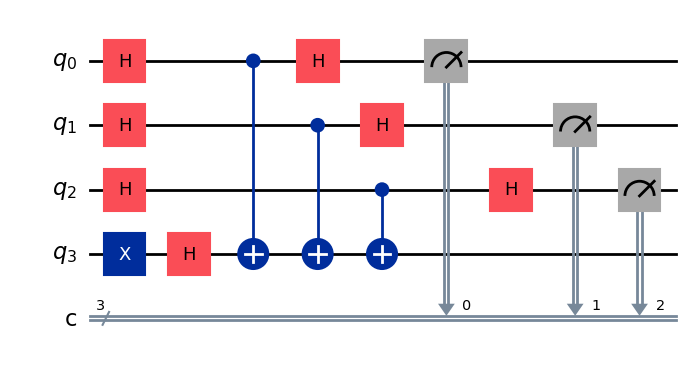

In [8]:
# Build the circuit
qc = build_deutsch_jozsa(3, oracle_type="balanced")

qc.draw("mpl")

In [10]:
# Compile the circuit
# Real quantum computers require optimization
transpiled_circuit = transpile(qc, backend)

In [ ]:
# Create sampler with real backend
sampler = SamplerV2(mode=backend)

# Run circuit
job = sampler.run([transpiled_circuit])

In [ ]:
# Extract counts
data = result[0].data

first_key = list(data.__dict__.keys())[0]

counts_real = getattr(data, first_key).get_counts()
counts_real

{'111': 3863,
 '001': 18,
 '011': 54,
 '000': 39,
 '101': 68,
 '110': 50,
 '100': 2,
 '010': 2}


The results obtained from IBM Quantum hardware show that the dominant output state is '111', which indicates a balanced function according to the Deutsch-Jozsa algorithm.

However, other states appear with smaller frequencies due to quantum noise and hardware imperfections such as decoherence and gate errors.

This experiment demonstrates that while quantum algorithms work correctly in real hardware, noise significantly affects the measurements compared to ideal simulations.

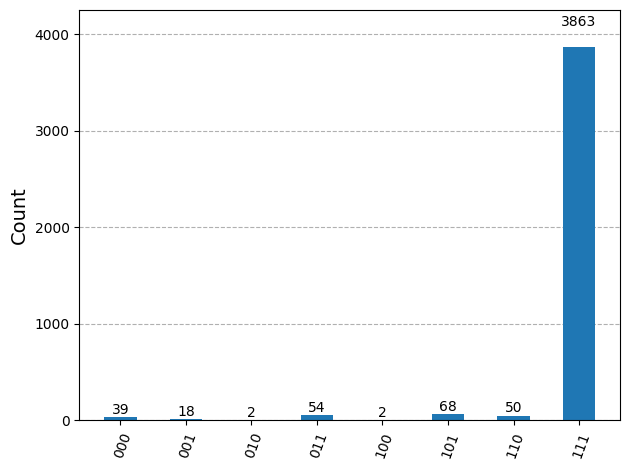

In [19]:
# Plot
plot_histogram(counts_real)

In [22]:
# Save results
fig = plot_histogram(counts_real)

fig.savefig("../results/figures/ibm_quantum_results.png", dpi=300)

In [24]:
# Save the data
with open("../results/ibm_results.json", "w") as f:
    json.dump(counts_real, f)

### Comparison with Simulator

In the simulator the algorithm produced a deterministic result. On real quantum hardware we observe additional measurement outcomes due to quantum noise and hardware imperfections.

### Discussion

The real quantum hardware introduces noise, which causes deviations from the ideal theoretical results. Despite this noise, the Deutsch–Jozsa algorithm still clearly identifies the function as balanced since the dominant measurement outcome differs from 000.